# Cursos de Machine Learning en el Sector Bancario
## Modulo. `Seguro de Autos para préstamos vehiculares con Machine Learning`
                        Elaborado por: Naren Castellon

## `Dataset para predicción de riesgo en seguros de autos vinculados a préstamos vehiculares'


# - client_id: ID único del cliente
# - ds: Fecha diaria (timestamp, para actualizaciones de préstamo/vehículo)
# - age: Edad (18-70)
# - gender: Género ('male', 'female')
# - annual_income: Ingreso anual (USD)
# - credit_score: Score crediticio (300-850)
# - debt_to_income_ratio: Ratio deuda/ingreso (0-0.6)
# - loan_amount: Monto del préstamo (USD, 10k-100k)
# - vehicle_value: Valor del vehículo (USD)
# - down_payment: Pago inicial (USD)
# - vehicle_type: Tipo de vehículo ('sedan', 'SUV', 'truck', 'luxury', 'sports')
# - vehicle_year: Año del vehículo (2010-2024)
# - annual_mileage: Kilometraje anual (km)
# - driving_history_accidents: Accidentes últimos 5 años (0-5)
# - location_risk: Riesgo por ubicación ('urban_high', 'urban_low', 'rural')
# - loan_term_months: Plazo del préstamo (meses, 36-84)
# - interest_rate: Tasa de interés (%)
# - payment_history_late: Pagos atrasados previos (0/1)
# - insurance_coverage_level: Nivel de cobertura solicitada ('basic', 'comprehensive')
# - high_risk_event: Target (1 si alta probabilidad de siniestro o incumplimiento, lógica: bajo score, alto DTI, accidentes, alto kilometraje, etc.)
# Frecuencia diaria: Actualizaciones diarias de kilometraje/pagos para monitoreo continuo.


In [2]:
import pandas as pd  # Para manipulación de datos, creación de DataFrames y manejo de grandes datasets
import numpy as np   # Para generación de datos sintéticos numéricos, operaciones matemáticas y arrays
from datetime import datetime, timedelta  # Para generar fechas diarias secuenciales
import random  # Para selección aleatoria de categorías y variabilidad
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de dispersión y matrices de confusión
import seaborn as sns  # Para gráficos avanzados en EDA, como heatmaps o distribuciones
from sklearn.model_selection import train_test_split  # Para dividir el dataset en train/test
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Para codificar categóricas y escalar numéricas (importante para ML)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc  # Métricas para evaluar modelo en clases desbalanceadas
from xgboost import XGBClassifier  # Modelo principal: XGBoost para Gradient Boosting (eficiente, maneja desbalance y categóricas con encoding)
import shap  # Para explicabilidad: SHAP values para entender contribuciones de features al modelo
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia

In [3]:
def generate_auto_loan_risk_data(num_clients=500, num_days=200):
    """
    Genera dataset sintético de clientes con préstamos vehiculares y riesgo de siniestros/incumplimiento, frecuencia diaria.
    - num_clients: Número de clientes únicos.
    - num_days: Días totales (total registros ~ num_clients * num_days).
    Retorna DataFrame con variables realistas para predicción de riesgo.
    """
    np.random.seed(42)  # Reproducibilidad
    
    data = []
    
    start_date = datetime(2023, 1, 1)  # Inicio para datos recientes
    
    # Mapeo de tipos de vehículo (para realismo)
    vehicle_types = ['sedan', 'SUV', 'truck', 'luxury', 'sports']
    
    for client in range(1, num_clients + 1):
        client_id = f'Client_{client}'  # ID único
        dates = pd.date_range(start=start_date, periods=num_days, freq='D')  # Fechas diarias
        
        # Generar 1 actualización diaria (para ~100k total)
        for i in range(num_days):
            # Edad: Fija + envejecimiento diario (simplificado)
            base_age = random.randint(18, 70)
            age = base_age + (i / 365)  # Envejece ligeramente
            
            # Género fijo
            gender = random.choice(['male', 'female'])
            
            # Ingreso anual fijo
            income = np.random.lognormal(10.8, 0.6)
            
            # Score crediticio: Correlacionado con edad/ingreso
            credit_score = 300 + (age / 70 * 200) + (income / 100000 * 350) + np.random.normal(0, 50)
            credit_score = np.clip(credit_score, 300, 850).astype(int)
            
            # DTI ratio: Bajo para altos ingresos
            dti = np.random.uniform(0.1, 0.4) if income > 60000 else np.random.uniform(0.3, 0.6)
            
            # Monto préstamo: 10k-100k
            loan_amount = random.uniform(10000, 100000)
            
            # Valor vehículo: Mayor que loan_amount
            vehicle_value = loan_amount * random.uniform(1.1, 1.5)
            
            # Pago inicial: 5-30% de vehicle_value
            down_payment = vehicle_value * random.uniform(0.05, 0.3)
            
            # Tipo vehículo
            vehicle_type = random.choice(vehicle_types)
            
            # Año vehículo: 2010-2024
            vehicle_year = random.randint(2010, 2024)
            
            # Kilometraje anual: Alto para riesgo
            annual_mileage = random.uniform(5000, 30000)
            
            # Accidentes últimos 5 años
            accidents = random.randint(0, 5)
            
            # Riesgo ubicación
            location_risk = random.choice(['urban_high', 'urban_low', 'rural'])
            
            # Plazo préstamo: 36-84 meses
            loan_term = random.choice([36, 48, 60, 72, 84])
            
            # Tasa interés: 4-15%
            interest_rate = random.uniform(4, 15)
            
            # Pagos atrasados previos
            late_payments = random.choice([0, 1])
            
            # Nivel cobertura solicitada
            coverage_level = random.choice(['basic', 'comprehensive'])
            
            # Alto riesgo: Lógica (bajo score, alto DTI, accidentes, alto kilometraje, viejo vehículo, pagos atrasados, etc.)
            high_risk_prob = 0.1 + 0.2 * (credit_score < 600) + 0.15 * (dti > 0.4) + 0.1 * accidents + 0.08 * (annual_mileage > 20000) + 0.07 * (vehicle_year < 2015) + 0.1 * late_payments + 0.05 * (location_risk == 'urban_high')
            is_high_risk = random.choices([0, 1], weights=[1 - min(high_risk_prob, 0.99), min(high_risk_prob, 0.99)])[0]
            
            data.append({
                'client_id': client_id,
                'ds': dates[i],
                'age': round(age, 1),
                'gender': gender,
                'annual_income': round(income, 2),
                'credit_score': credit_score,
                'debt_to_income_ratio': round(dti, 2),
                'loan_amount': round(loan_amount, 2),
                'vehicle_value': round(vehicle_value, 2),
                'down_payment': round(down_payment, 2),
                'vehicle_type': vehicle_type,
                'vehicle_year': vehicle_year,
                'annual_mileage': round(annual_mileage, 0),
                'driving_history_accidents': accidents,
                'location_risk': location_risk,
                'loan_term_months': loan_term,
                'interest_rate': round(interest_rate, 2),
                'payment_history_late': late_payments,
                'insurance_coverage_level': coverage_level,
                'is_high_risk': is_high_risk
            })
    
    df = pd.DataFrame(data)
    print(f"Dataset generado: {len(df)} registros con {len(df.columns)} variables (frecuencia diaria).")
    return df

# Generar dataset
auto_loan_df = generate_auto_loan_risk_data(num_clients=500, num_days=200)  # ~100k registros

# Guardar como CSV (opcional)
auto_loan_df.to_csv('auto_loan_risk_data.csv', index=False)

Dataset generado: 100000 registros con 20 variables (frecuencia diaria).


In [4]:
auto_loan_df = pd.read_csv('auto_loan_risk_data.csv')
auto_loan_df

,client_id,ds,age,gender,annual_income,credit_score,debt_to_income_ratio,loan_amount,vehicle_value,down_payment,vehicle_type,vehicle_year,annual_mileage,driving_history_accidents,location_risk,loan_term_months,interest_rate,payment_history_late,insurance_coverage_level,is_high_risk
0,Client_1,2023-01-01,60.0,male,66040.83,695,0.32,34774.62,44922.43,3016.09,luxury,2023,25928.0,4,urban_high,84,7.54,1,basic,0
1,Client_1,2023-01-02,19.0,male,25156.51,458,0.35,61671.63,83263.94,4490.78,sedan,2017,25258.0,2,rural,72,13.35,0,basic,0
2,Client_1,2023-01-03,32.0,female,126440.57,850,0.11,41881.24,56604.58,16036.46,luxury,2017,21845.0,4,urban_low,84,8.24,1,basic,1
3,Client_1,2023-01-04,48.0,male,34595.30,531,0.36,52328.22,76051.95,4022.30,SUV,2017,24112.0,3,urban_low,84,9.76,0,basic,1
4,Client_1,2023-01-05,62.0,male,56680.04,579,0.43,87858.38,110392.32,32376.10,truck,2019,23369.0,3,rural,72,4.17,1,basic,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Client_500,2023-07-15,68.5,male,63684.58,763,0.31,40480.64,47608.94,7250.76,truck,2019,16199.0,0,urban_high,72,10.98,1,basic,0
99996,Client_500,2023-07-16,35.5,male,63909.03,576,0.39,37673.70,42498.70,9989.18,luxury,2020,23794.0,5,rural,72,9.44,0,comprehensive,1
99997,Client_500,2023-07-17,55.5,female,59757.20,654,0.56,87874.50,112107.11,23888.60,sedan,2017,23943.0,1,urban_high,48,7.51,1,basic,0
99998,Client_500,2023-07-18,24.5,female,33219.38,543,0.56,94764.36,135000.07,34837.11,sedan,2018,25902.0,0,urban_high,48,6.26,1,comprehensive,1


In [5]:
# Paso 2: Análisis Exploratorio de Datos (EDA)
# Convertir ds a datetime
auto_loan_df['ds'] = pd.to_datetime(auto_loan_df['ds'])

In [6]:
# Resumen estadístico
print("\nEstadísticas descriptivas:")
print(auto_loan_df.describe())


Estadísticas descriptivas:
                                  ds            age  annual_income  \
count                         100000  100000.000000  100000.000000   
mean   2023-04-10 12:00:00.000000256      44.355430   58703.265273   
min              2023-01-01 00:00:00      18.000000    3348.710000   
25%              2023-02-19 18:00:00      31.100000   32717.662500   
50%              2023-04-10 12:00:00      44.300000   48987.675000   
75%              2023-05-30 06:00:00      57.500000   73396.230000   
max              2023-07-19 00:00:00      70.500000  513829.080000   
std                              NaN      15.336363   38430.290523   

        credit_score  debt_to_income_ratio    loan_amount  vehicle_value  \
count  100000.000000         100000.000000  100000.000000  100000.000000   
mean      620.846970              0.376545   55105.250009   71645.265742   
min       300.000000              0.100000   10000.560000   11078.300000   
25%       532.000000              0.3

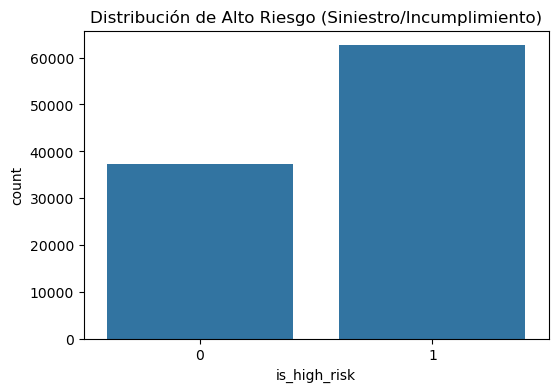

In [7]:
# Distribución de alto riesgo
plt.figure(figsize=(6, 4))
sns.countplot(x='is_high_risk', data=auto_loan_df)
plt.title('Distribución de Alto Riesgo (Siniestro/Incumplimiento)')
plt.show()

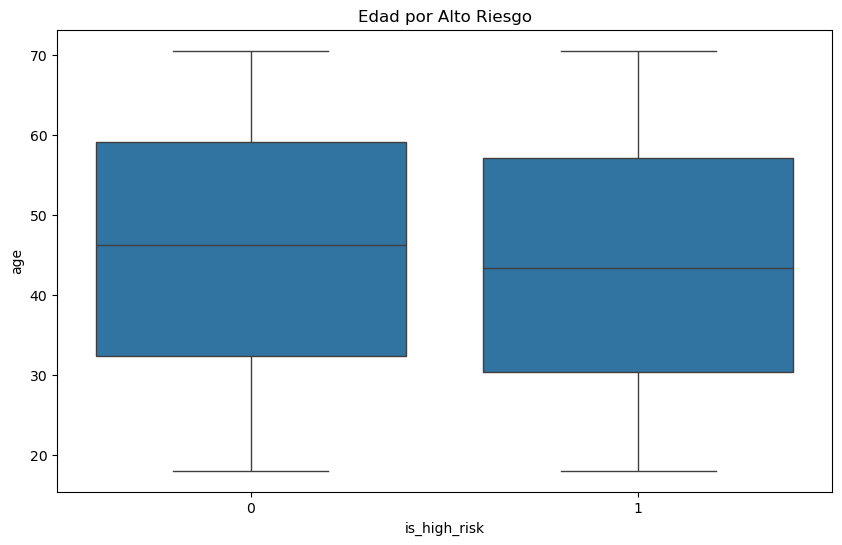

In [8]:
# Probabilidad por edad (scatter aproximado)
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_high_risk', y='age', data=auto_loan_df)
plt.title('Edad por Alto Riesgo')
plt.show()

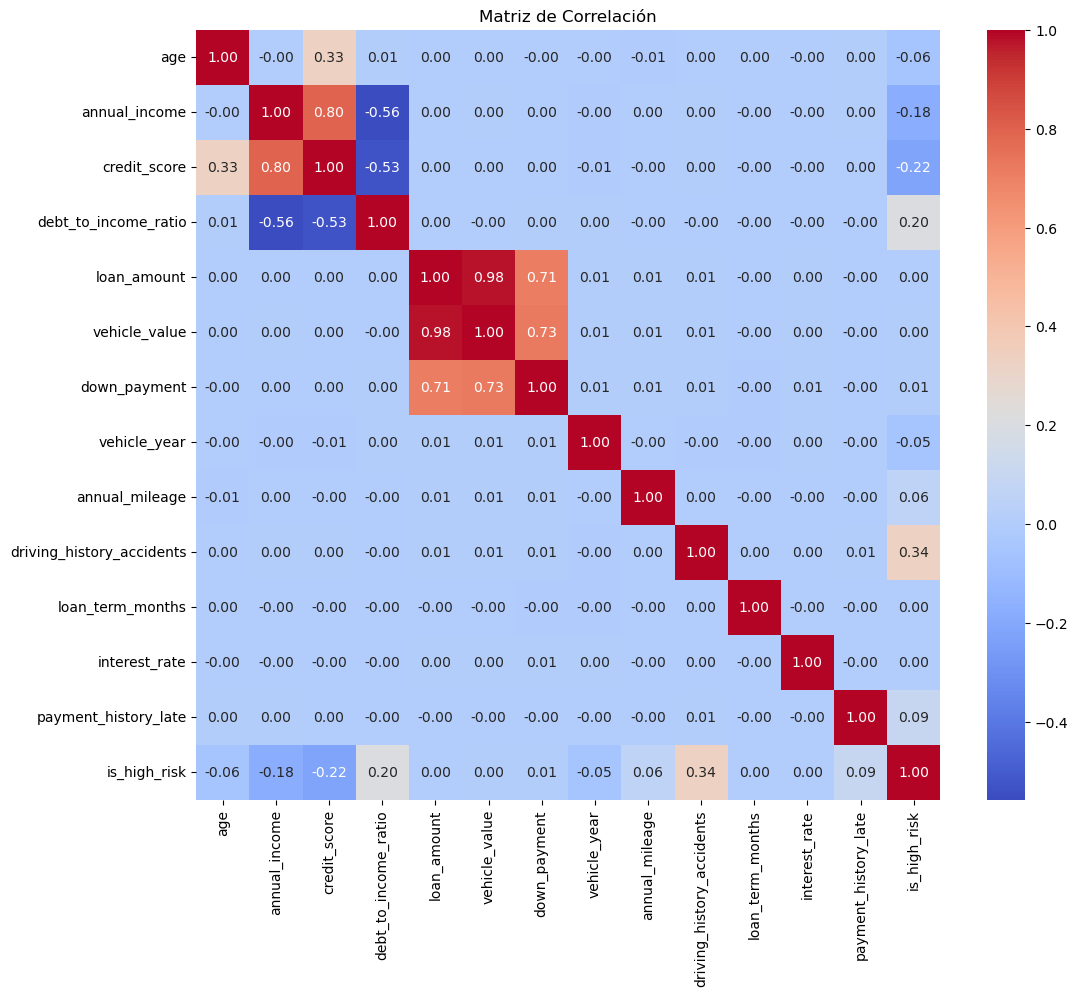

In [9]:
# Correlación numérica
numeric_cols = auto_loan_df.select_dtypes(include=[np.number]).columns
corr_matrix = auto_loan_df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [10]:
# Paso 3: Preprocesamiento para Gradient Boosting (XGBoost)
# Codificar categóricas
cat_cols = ['gender', 'vehicle_type', 'location_risk', 'insurance_coverage_level']
le_dict = {col: LabelEncoder().fit(auto_loan_df[col]) for col in cat_cols}
for col in cat_cols:
    auto_loan_df[col] = le_dict[col].transform(auto_loan_df[col])

In [11]:
# Escalar numéricas (útil para regularización)
num_cols = ['age', 'annual_income', 'credit_score', 'debt_to_income_ratio', 'loan_amount', 'vehicle_value', 'down_payment', 'interest_rate', 'annual_mileage', 'vehicle_year']
scaler = StandardScaler()
auto_loan_df[num_cols] = scaler.fit_transform(auto_loan_df[num_cols])

In [12]:

# Dividir train/test (estratificado por alto riesgo)
X = auto_loan_df.drop(columns=['client_id', 'ds', 'is_high_risk'])
y = auto_loan_df['is_high_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [13]:
# Paso 4: Definir y Entrenar Gradient Boosting (XGBoost)
# XGBoost: Gradient Boosting eficiente, maneja desbalance con scale_pos_weight, rápido y preciso para riesgo
pos_weight = (y == 0).sum() / (y == 1).sum()  # Para desbalance (alto riesgo raro)
gb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1
)

gb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [14]:
gb_model.fit(X_train, y_train)

print("Modelo Gradient Boosting (XGBoost) entrenado.")

Modelo Gradient Boosting (XGBoost) entrenado.


In [15]:
# Paso 5: Evaluación del Modelo
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]

In [16]:
# Reporte y métricas
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.56      0.73      0.63      7473
           1       0.80      0.66      0.72     12527

    accuracy                           0.69     20000
   macro avg       0.68      0.69      0.68     20000
weighted avg       0.71      0.69      0.69     20000



In [17]:
roc_auc = roc_auc_score(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.7702
PR-AUC: 0.8544


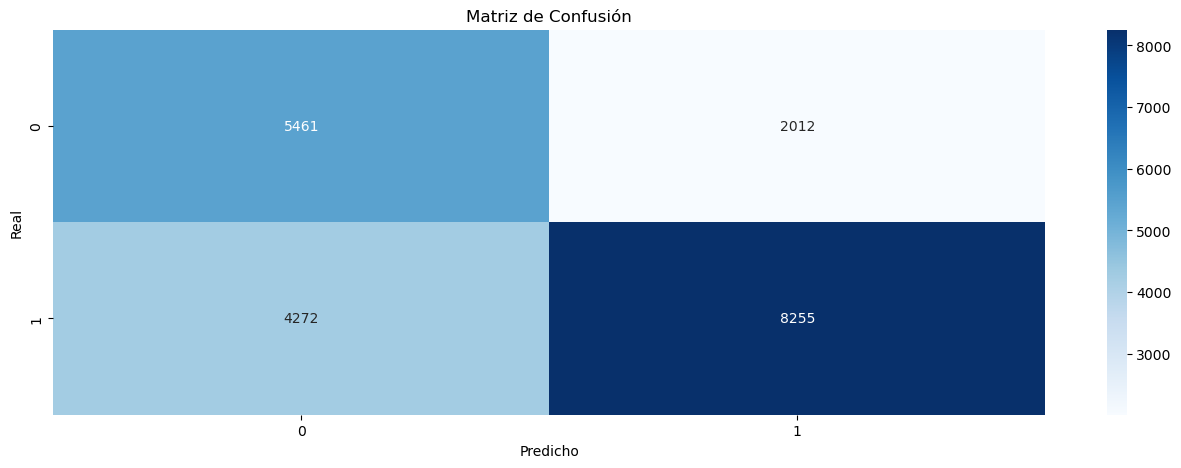

In [19]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

In [20]:
# Paso 6: Sección para Medir el Riesgo de Siniestros/Incumplimiento
# Riesgo: Basado en probabilidad (bajo <30%, medio 30-70%, alto >70%)
risk_levels = pd.cut(y_prob, bins=[0, 0.3, 0.7, 1.0], labels=['Bajo Riesgo', 'Medio Riesgo', 'Alto Riesgo'])
risk_df = pd.DataFrame({'Probabilidad': y_prob, 'Riesgo': risk_levels, 'Real Alto Riesgo': y_test})
print("\nDistribución de Riesgo en Test Set:")
print(risk_df['Riesgo'].value_counts(normalize=True))


Distribución de Riesgo en Test Set:
Riesgo
Medio Riesgo    0.5419
Alto Riesgo     0.2591
Bajo Riesgo     0.1990
Name: proportion, dtype: float64


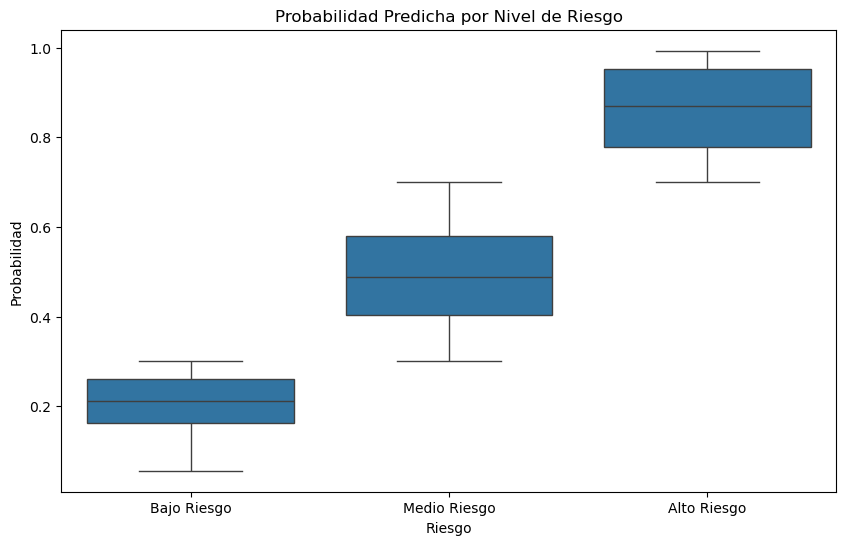

In [21]:
# Visualizar riesgo
plt.figure(figsize=(10, 6))
sns.boxplot(x='Riesgo', y='Probabilidad', data=risk_df)
plt.title('Probabilidad Predicha por Nivel de Riesgo')
plt.show()

In [22]:
# Paso 7: Sección de Predicción con Perfil del Cliente
# Ejemplo: Predicción para un cliente nuevo, mostrar perfil y probabilidad de siniestro/incumplimiento
example_input_raw = {
    'age': 35,
    'gender': 'male',
    'annual_income': 60000,
    'credit_score': 650,
    'debt_to_income_ratio': 0.35,
    'loan_amount': 30000,
    'vehicle_value': 35000,
    'down_payment': 5000,
    'vehicle_type': 'SUV',
    'vehicle_year': 2020,
    'annual_mileage': 15000,
    'driving_history_accidents': 1,
    'location_risk': 'urban_high',
    'loan_term_months': 60,
    'interest_rate': 7.5,
    'payment_history_late': 0,
    'insurance_coverage_level': 'comprehensive'
}

# Preprocesar ejemplo
example_df = pd.DataFrame([example_input_raw])
for col in le_dict:
    if col in example_df.columns:
        example_df[col] = le_dict[col].transform([example_df[col][0]])
example_df[num_cols] = scaler.transform(example_df[num_cols])
example_df = example_df.reindex(columns=X.columns, fill_value=0)

pred_prob = gb_model.predict_proba(example_df)[0][1]

print("\n--- Predicción para Cliente Ejemplo ---")
print("Perfil del Cliente:")
print(f"- Edad: {example_input_raw['age']}")
print(f"- Género: {example_input_raw['gender']}")
print(f"- Ingreso Anual: ${example_input_raw['annual_income']}")
print(f"- Score Crediticio: {example_input_raw['credit_score']}")
print(f"- Ratio Deuda/Ingreso: {example_input_raw['debt_to_income_ratio']}")
print(f"- Tipo de Vehículo: {example_input_raw['vehicle_type']}")
print(f"- Año del Vehículo: {example_input_raw['vehicle_year']}")
print(f"- Kilometraje Anual: {example_input_raw['annual_mileage']}")
print(f"- Plazo del Préstamo: {example_input_raw['loan_term_months']} meses")

print("\nResultados:")
print(f"Probabilidad de Siniestro o Incumplimiento: {pred_prob:.2%}")
risk_level = "Bajo" if pred_prob < 0.3 else "Medio" if pred_prob < 0.7 else "Alto"
print(f"Nivel de Riesgo: {risk_level}")

# Prima sugerida para seguro (ejemplo)
base_premium = 800
factor = 2 if risk_level == "Alto" else 1.5 if risk_level == "Medio" else 1
suggested_premium = base_premium * factor + pred_prob * example_input_raw['vehicle_value'] * 0.01
print(f"Prima Sugerida Anual para Seguro: ${suggested_premium:.2f}")


--- Predicción para Cliente Ejemplo ---
Perfil del Cliente:
- Edad: 35
- Género: male
- Ingreso Anual: $60000
- Score Crediticio: 650
- Ratio Deuda/Ingreso: 0.35
- Tipo de Vehículo: SUV
- Año del Vehículo: 2020
- Kilometraje Anual: 15000
- Plazo del Préstamo: 60 meses

Resultados:
Probabilidad de Siniestro o Incumplimiento: 16.51%
Nivel de Riesgo: Bajo
Prima Sugerida Anual para Seguro: $857.77


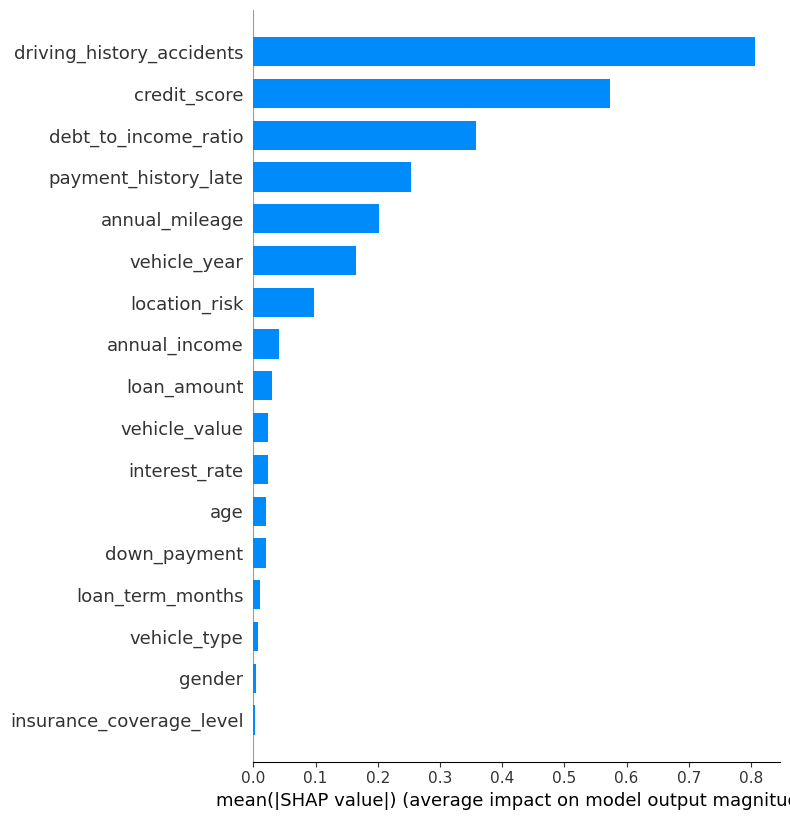

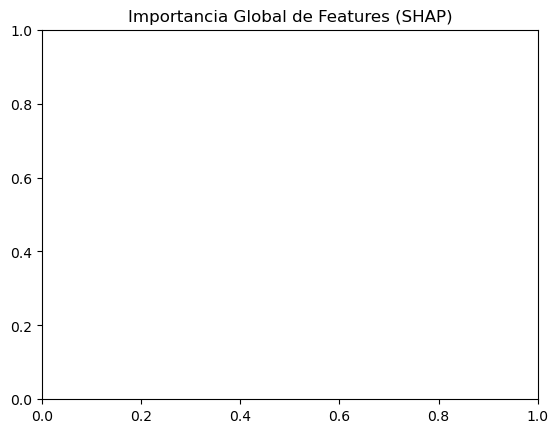

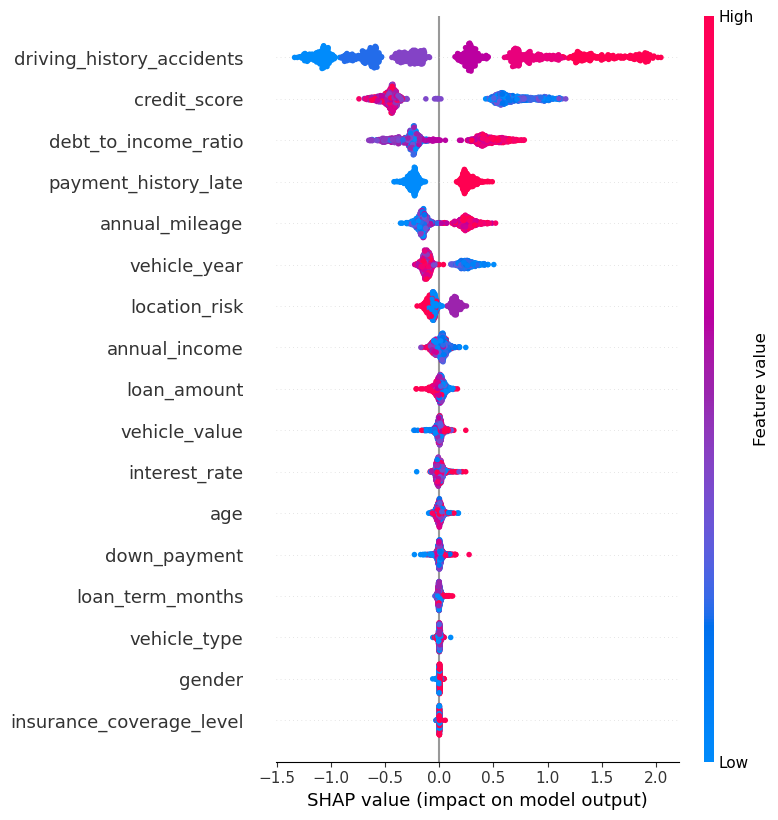

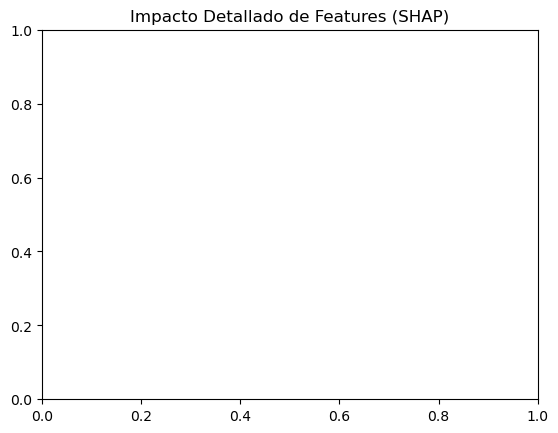

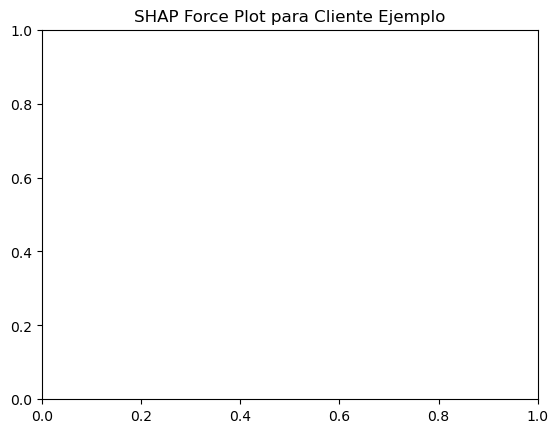

In [23]:
# Paso 8: Implementar SHAP para Explicabilidad
# SHAP: Analiza contribuciones de features a predicciones (crucial para transparencia en seguros/préstamos)
explainer = shap.TreeExplainer(gb_model)

# SHAP values en muestra de test
X_test_sample = X_test.sample(1000)
shap_values = explainer.shap_values(X_test_sample)

# Resumen global
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")
plt.title('Importancia Global de Features (SHAP)')
plt.show()

# Resumen detallado
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample)
plt.title('Impacto Detallado de Features (SHAP)')
plt.show()

# Ejemplo individual (primera instancia)
shap.force_plot(explainer.expected_value, shap_values[0], X_test_sample.iloc[0])
plt.title('SHAP Force Plot para Cliente Ejemplo')
plt.show()


Análisis de Sensibilidad Robusta (Monte Carlo con 100 perturbaciones):
Varianza Promedio en Probabilidad: 0.0033
Delta Máximo Promedio en Probabilidad: 0.1505


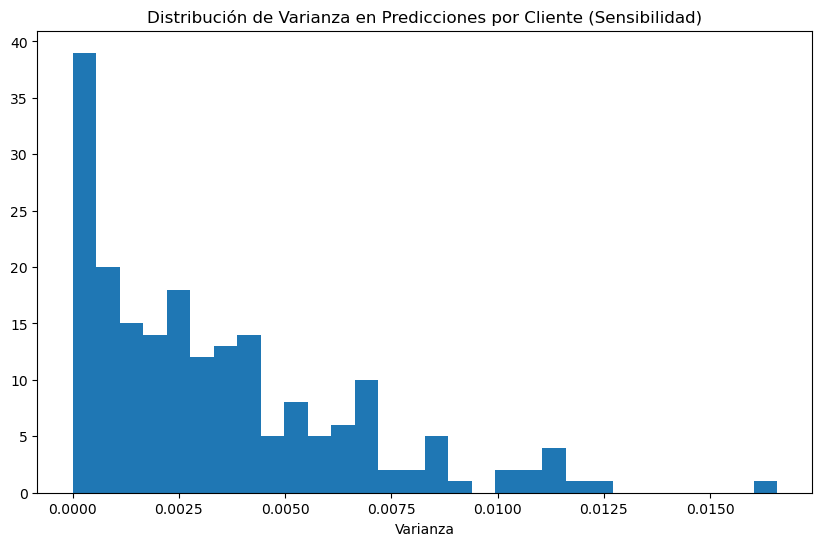

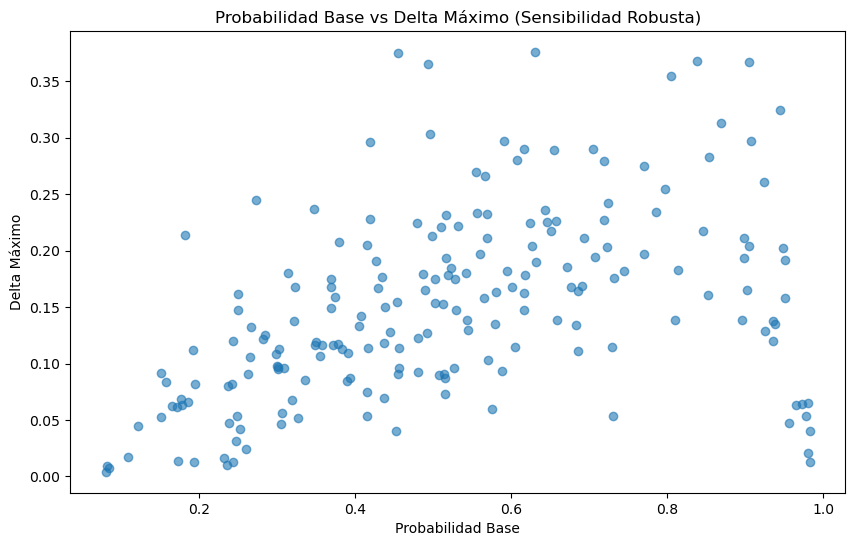


¡Análisis de sensibilidad robusta agregado! Usa Monte Carlo para evaluar variabilidad ante perturbaciones múltiples.
- Útil para seguros/préstamos: Identifica clientes donde predicción es sensible (incertidumbre alta → revisión manual).
- Recomendación: En producción, integra con incertidumbre del modelo para decisiones robustas.

¡Ejemplo end-to-end completado con riesgo, SHAP y análisis de sensibilidad robusta! Gradient Boosting (XGBoost) predice riesgo en préstamos autos.
- Riesgo: Categoriza probabilidad para ofertas/primas ajustadas.
- SHAP: Explica contribuciones (e.g., accidentes aumentan riesgo).
- Sensibilidad Robusta: Monte Carlo para variabilidad realista.
- Recomendación: En producción, usa para scoring dinámico y compliance en banca.


In [25]:


# Paso 9: Análisis de Sensibilidad Robusta
# Análisis de sensibilidad robusta: Perturba múltiples features simultáneamente y mide variabilidad en predicción
# Método: Monte Carlo - 100 perturbaciones por muestra (muestra de 200 clientes), variar ±10-20% en features clave
# Calcula varianza de predicción y delta máximo para robustez
sensitivity_sample = X_test.sample(200)
base_pred = gb_model.predict_proba(sensitivity_sample)[:, 1]

num_perturbations = 100
perturbed_preds = np.zeros((len(sensitivity_sample), num_perturbations))

key_features = ['age', 'credit_score', 'debt_to_income_ratio', 'annual_mileage', 'driving_history_accidents', 'vehicle_year']

for p in range(num_perturbations):
    perturbed = sensitivity_sample.copy()
    for feat in key_features:
        if feat in key_features:  # Numéricas
            perturbation = np.random.uniform(0.8, 1.2)  # ±20%
            perturbed[feat] *= perturbation
        # Para categóricas, podría cambiar categoría, pero simplificamos a numéricas clave
    perturbed_preds[:, p] = gb_model.predict_proba(perturbed)[:, 1]

# Métricas de sensibilidad robusta
variance_per_sample = np.var(perturbed_preds, axis=1)
max_delta_per_sample = np.max(perturbed_preds, axis=1) - np.min(perturbed_preds, axis=1)
avg_variance = np.mean(variance_per_sample)
avg_max_delta = np.mean(max_delta_per_sample)

print("\nAnálisis de Sensibilidad Robusta (Monte Carlo con 100 perturbaciones):")
print(f"Varianza Promedio en Probabilidad: {avg_variance:.4f}")
print(f"Delta Máximo Promedio en Probabilidad: {avg_max_delta:.4f}")

# Visualizar variabilidad por muestra
plt.figure(figsize=(10, 6))
plt.hist(variance_per_sample, bins=30)
plt.title('Distribución de Varianza en Predicciones por Cliente (Sensibilidad)')
plt.xlabel('Varianza')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(base_pred, max_delta_per_sample, alpha=0.6)
plt.title('Probabilidad Base vs Delta Máximo (Sensibilidad Robusta)')
plt.xlabel('Probabilidad Base')
plt.ylabel('Delta Máximo')
plt.show()

print("\n¡Análisis de sensibilidad robusta agregado! Usa Monte Carlo para evaluar variabilidad ante perturbaciones múltiples.")
print("- Útil para seguros/préstamos: Identifica clientes donde predicción es sensible (incertidumbre alta → revisión manual).")
print("- Recomendación: En producción, integra con incertidumbre del modelo para decisiones robustas.")

print("\n¡Ejemplo end-to-end completado con riesgo, SHAP y análisis de sensibilidad robusta! Gradient Boosting (XGBoost) predice riesgo en préstamos autos.")
print("- Riesgo: Categoriza probabilidad para ofertas/primas ajustadas.")
print("- SHAP: Explica contribuciones (e.g., accidentes aumentan riesgo).")
print("- Sensibilidad Robusta: Monte Carlo para variabilidad realista.")
print("- Recomendación: En producción, usa para scoring dinámico y compliance en banca.")